## Part 1: Import Libraries and Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, mean_absolute_error, mean_squared_error

np.random.seed(42)
sns.set_style("whitegrid")
%matplotlib inline

In [2]:
df = pd.read_csv("train.csv")

if df.columns[0].startswith("Unnamed"):
    df = df.drop(columns=[df.columns[0]])

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
df.head()

Number of rows: 103904
Number of columns: 24


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [3]:
df.info()
print()
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 103904 non-null  int64  
 1   Gender                             103904 non-null  str    
 2   Customer Type                      103904 non-null  str    
 3   Age                                103904 non-null  int64  
 4   Type of Travel                     103904 non-null  str    
 5   Class                              103904 non-null  str    
 6   Flight Distance                    103904 non-null  int64  
 7   Inflight wifi service              103904 non-null  int64  
 8   Departure/Arrival time convenient  103904 non-null  int64  
 9   Ease of Online booking             103904 non-null  int64  
 10  Gate location                      103904 non-null  int64  
 11  Food and drink                     103904 non-null

In [4]:
df = df.dropna().reset_index(drop=True)
print("Number of rows after dropna:", df.shape[0])

Number of rows after dropna: 103594


In [5]:
input_cols = [
    "Inflight wifi service",
    "Food and drink",
    "Seat comfort",
    "Inflight entertainment",
    "Online boarding",
]
target_col = "satisfaction"

df[input_cols].describe()

,Inflight wifi service,Food and drink,Seat comfort,Inflight entertainment,Online boarding
count,103594.000000,103594.000000,103594.000000,103594.000000,103594.000000
mean,2.729753,3.202126,3.439765,3.358341,3.250497
std,1.327866,1.329401,1.318896,1.333030,1.349433
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,2.000000,2.000000,2.000000
50%,3.000000,3.000000,4.000000,4.000000,3.000000
75%,4.000000,4.000000,5.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000


In [6]:
df[target_col].value_counts()

satisfaction
neutral or dissatisfied    58697
satisfied                  44897
Name: count, dtype: int64

In [7]:
SAMPLE_SIZE = 5000
df_sample = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
print("Number of rows used:", df_sample.shape[0])
df_sample[input_cols + [target_col]].head()

Number of rows used: 5000


,Inflight wifi service,Food and drink,Seat comfort,Inflight entertainment,Online boarding,satisfaction
0,5,2,1,5,4,satisfied
1,2,1,1,1,2,neutral or dissatisfied
2,1,5,5,5,1,neutral or dissatisfied
3,3,4,3,3,3,neutral or dissatisfied
4,4,4,4,4,4,satisfied


## Part 2: Exploratory Data Analysis

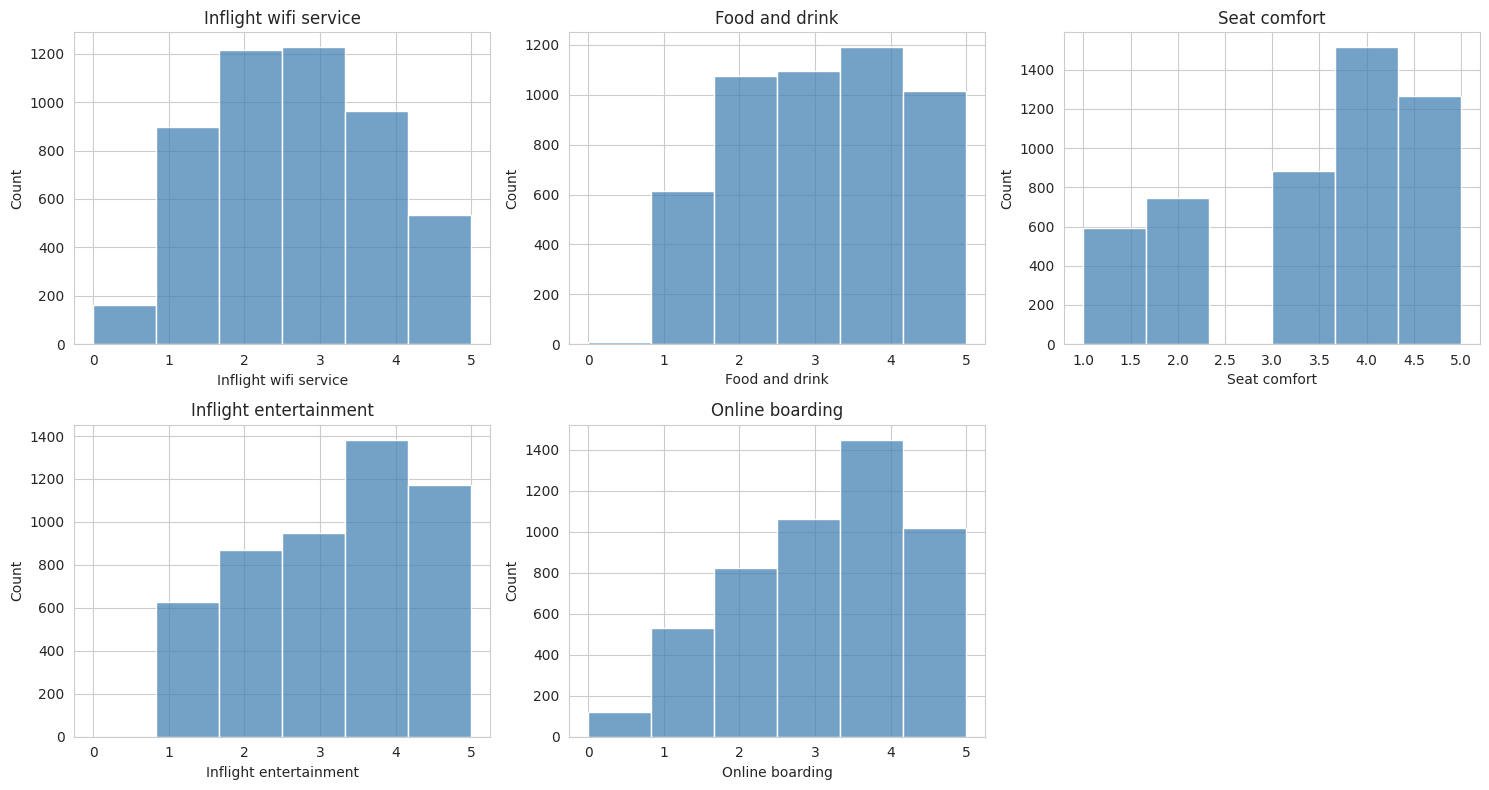

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(input_cols):
    ax = axes[i // 3, i % 3]
    sns.histplot(df_sample[col], bins=6, kde=False, ax=ax, color="steelblue")
    ax.set_title(col)
axes[1, 2].axis("off")
plt.tight_layout()
plt.show()

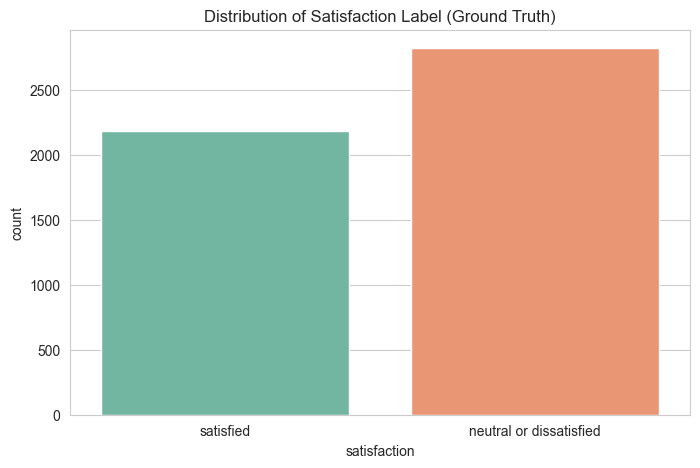

In [25]:
plt.figure(figsize=(8, 5))
sns.countplot(x=target_col, data=df_sample, hue=target_col, palette="Set2", legend=False)
plt.title("Distribution of Satisfaction Label (Ground Truth)")
plt.show()

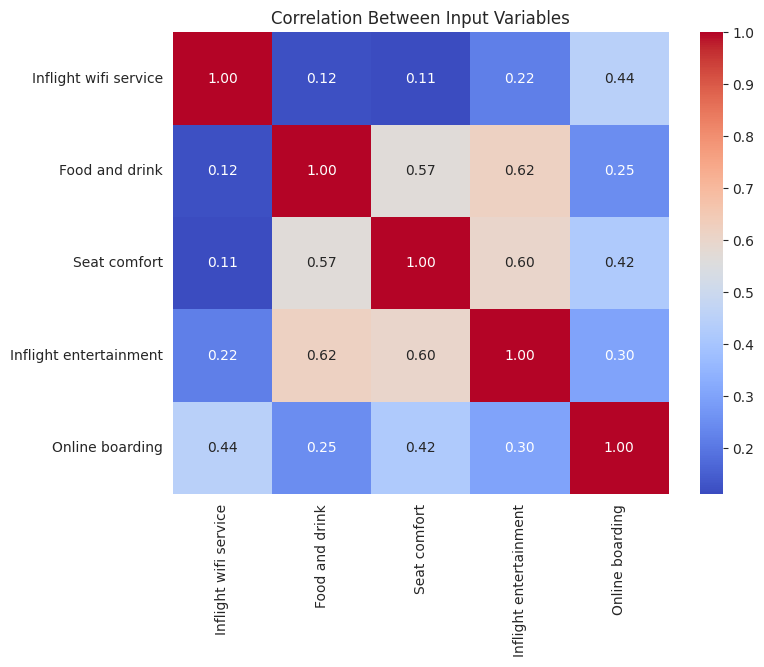

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_sample[input_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Input Variables")
plt.show()

## Part 3: Fuzzy Logic Design — Linguistic Variables and Membership Functions


In [11]:
def trimf(x, params):
    a, b, c = params
    if x <= a or x >= c:
        return 0.0
    elif a < x <= b:
        return (x - a) / (b - a) if b != a else 1.0
    else:
        return (c - x) / (c - b) if c != b else 1.0

def trapmf(x, params):
    a, b, c, d = params
    if x <= a or x >= d:
        return 0.0
    elif a < x < b:
        return (x - a) / (b - a) if b != a else 1.0
    elif b <= x <= c:
        return 1.0
    else:
        return (d - x) / (d - c) if d != c else 1.0

In [12]:
INPUT_SETS = {
    "poor":    {"type": "trap", "params": [0, 0, 1, 2.5]},
    "average": {"type": "tri",  "params": [1, 2.5, 4]},
    "good":    {"type": "trap", "params": [2.5, 4, 5, 5]},
}

def fuzzify_input(x):
    result = {}
    for label, mf in INPUT_SETS.items():
        if mf["type"] == "tri":
            result[label] = trimf(x, mf["params"])
        else:
            result[label] = trapmf(x, mf["params"])
    return result

In [13]:
OUTPUT_SETS = {
    "low":    {"type": "trap", "params": [0, 0, 30, 50]},
    "medium": {"type": "tri",  "params": [30, 50, 70]},
    "high":   {"type": "trap", "params": [50, 70, 100, 100]},
}

def output_mf(x, label):
    mf = OUTPUT_SETS[label]
    if mf["type"] == "tri":
        return trimf(x, mf["params"])
    else:
        return trapmf(x, mf["params"])

In [14]:
def plot_membership(sets, x_range, title, xlabel):
    x_vals = np.linspace(x_range[0], x_range[1], 200)
    plt.figure(figsize=(7, 4))
    for label, mf in sets.items():
        y_vals = [trimf(v, mf["params"]) if mf["type"] == "tri" else trapmf(v, mf["params"]) for v in x_vals]
        plt.plot(x_vals, y_vals, label=label)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Membership Degree")
    plt.legend()
    plt.show()

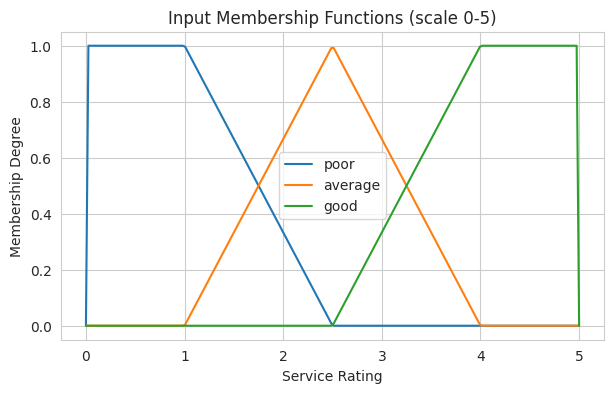

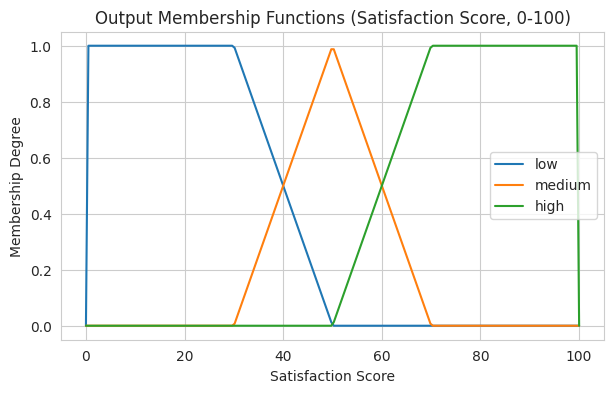

In [15]:
plot_membership(INPUT_SETS, x_range=(0, 5), title="Input Membership Functions (scale 0-5)", xlabel="Service Rating")

plot_membership(OUTPUT_SETS, x_range=(0, 100), title="Output Membership Functions (Satisfaction Score, 0-100)", xlabel="Satisfaction Score")

## Part 4: Rule Base

Each input is fuzzified into 3 sets (`poor`, `average`, `good`), then combined into **20 rules** (minimum required: 15) using the **AND (min)** operator. The general idea: if most services are rated good, satisfaction is high; if most are rated poor, satisfaction is low.

Notation: `wifi`, `food`, `seat`, `entertainment`, `boarding` each take the value `poor` / `average` / `good`.

| No | wifi | food | seat | entertainment | boarding | THEN Satisfaction |
|----|------|------|------|----------------|----------|-------------------|
| 1 | good | good | good | good | good | High |
| 2 | good | good | good | average | good | High |
| 3 | good | average | good | good | average | High |
| 4 | average | good | good | good | good | High |
| 5 | good | good | average | good | average | High |
| 6 | average | average | average | average | average | Medium |
| 7 | average | average | good | average | average | Medium |
| 8 | good | poor | average | average | average | Medium |
| 9 | average | good | poor | average | good | Medium |
| 10 | average | average | average | good | poor | Medium |
| 11 | poor | average | average | average | average | Medium |
| 12 | average | poor | average | poor | average | Low |
| 13 | poor | poor | poor | poor | poor | Low |
| 14 | poor | poor | average | poor | average | Low |
| 15 | poor | average | poor | average | poor | Low |
| 16 | average | poor | poor | poor | average | Low |
| 17 | poor | poor | poor | average | poor | Low |
| 18 | good | poor | poor | poor | poor | Medium |
| 19 | average | average | poor | poor | poor | Low |
| 20 | good | good | poor | average | poor | Medium |

This rule base is shared by both **Mamdani** (consequent = output fuzzy set) and **Sugeno** (consequent = linear function, see Part 6).


In [16]:
RULES = [
    ("good",    "good",    "good",    "good",    "good",    "high"),
    ("good",    "good",    "good",    "average", "good",    "high"),
    ("good",    "average", "good",    "good",    "average", "high"),
    ("average", "good",    "good",    "good",    "good",    "high"),
    ("good",    "good",    "average", "good",    "average", "high"),
    ("average", "average", "average", "average", "average", "medium"),
    ("average", "average", "good",    "average", "average", "medium"),
    ("good",    "poor",    "average", "average", "average", "medium"),
    ("average", "good",    "poor",    "average", "good",    "medium"),
    ("average", "average", "average", "good",    "poor",    "medium"),
    ("poor",    "average", "average", "average", "average", "medium"),
    ("average", "poor",    "average", "poor",    "average", "low"),
    ("poor",    "poor",    "poor",    "poor",    "poor",    "low"),
    ("poor",    "poor",    "average", "poor",    "average", "low"),
    ("poor",    "average", "poor",    "average", "poor",    "low"),
    ("average", "poor",    "poor",    "poor",    "average", "low"),
    ("poor",    "poor",    "poor",    "average", "poor",    "low"),
    ("good",    "poor",    "poor",    "poor",    "poor",    "medium"),
    ("average", "average", "poor",    "poor",    "poor",    "low"),
    ("good",    "good",    "poor",    "average", "poor",    "medium"),
]

print("Number of rules:", len(RULES))

Number of rules: 20


## Part 5: Mamdani Fuzzy Inference


In [17]:
def mamdani_inference(wifi, food, seat, entertainment, boarding, x_out=None):
    if x_out is None:
        x_out = np.linspace(0, 100, 101)

    fz_wifi  = fuzzify_input(wifi)
    fz_food  = fuzzify_input(food)
    fz_seat  = fuzzify_input(seat)
    fz_ent   = fuzzify_input(entertainment)
    fz_board = fuzzify_input(boarding)
    fuzzified = [fz_wifi, fz_food, fz_seat, fz_ent, fz_board]

    aggregated = np.zeros_like(x_out, dtype=float)

    for rule in RULES:
        antecedents, consequent = rule[:5], rule[5]

        strengths = [fuzzified[i][antecedents[i]] for i in range(5)]
        alpha = min(strengths)

        if alpha > 0:
            implicated = np.array([min(alpha, output_mf(x, consequent)) for x in x_out])
            aggregated = np.maximum(aggregated, implicated)

    if aggregated.sum() == 0:
        return 50.0 
    centroid = np.sum(x_out * aggregated) / np.sum(aggregated)
    return centroid

In [18]:
sample_row = df_sample.iloc[0]

score_mamdani = mamdani_inference(
    sample_row["Inflight wifi service"],
    sample_row["Food and drink"],
    sample_row["Seat comfort"],
    sample_row["Inflight entertainment"],
    sample_row["Online boarding"],
)

print("Input :", sample_row[input_cols].to_dict())
print("Mamdani Satisfaction Score :", round(score_mamdani, 2))
print("Ground truth label         :", sample_row[target_col])

Input : {'Inflight wifi service': 5, 'Food and drink': 2, 'Seat comfort': 1, 'Inflight entertainment': 5, 'Online boarding': 4}
Mamdani Satisfaction Score : 50.0
Ground truth label         : satisfied


In [19]:
x_out_grid = np.linspace(0, 100, 101)
mamdani_scores = []

for _, row in df_sample.iterrows():
    score = mamdani_inference(
        row["Inflight wifi service"],
        row["Food and drink"],
        row["Seat comfort"],
        row["Inflight entertainment"],
        row["Online boarding"],
        x_out=x_out_grid,
    )
    mamdani_scores.append(score)

df_sample["mamdani_score"] = mamdani_scores
df_sample["mamdani_label"] = np.where(df_sample["mamdani_score"] >= 50, "satisfied", "neutral or dissatisfied")

df_sample[input_cols + ["mamdani_score", "mamdani_label", target_col]].head(10)

,Inflight wifi service,Food and drink,Seat comfort,Inflight entertainment,Online boarding,mamdani_score,mamdani_label,satisfaction
0,5,2,1,5,4,50.000000,satisfied,satisfied
1,2,1,1,1,2,22.085814,neutral or dissatisfied,neutral or dissatisfied
2,1,5,5,5,1,50.000000,satisfied,neutral or dissatisfied
3,3,4,3,3,3,76.384615,satisfied,neutral or dissatisfied
4,4,4,4,4,4,79.329114,satisfied,satisfied
5,2,5,4,4,5,50.000000,satisfied,satisfied
6,4,1,2,2,2,50.000000,satisfied,satisfied
7,3,1,1,1,3,22.085814,neutral or dissatisfied,neutral or dissatisfied
8,2,2,2,2,2,37.409750,neutral or dissatisfied,neutral or dissatisfied
9,4,4,4,4,4,79.329114,satisfied,satisfied


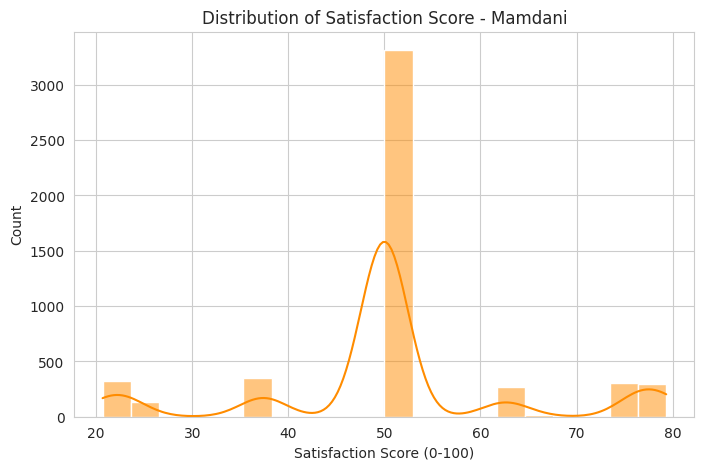

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(df_sample["mamdani_score"], bins=20, kde=True, color="darkorange")
plt.title("Distribution of Satisfaction Score - Mamdani")
plt.xlabel("Satisfaction Score (0-100)")
plt.show()

## Part 6: Sugeno Fuzzy Inference (From Scratch)


In [21]:
def sugeno_consequent(label, wifi, food, seat, entertainment, boarding):
    base = 4 * (wifi + food + seat + entertainment + boarding)
    if label == "low":
        z = base
    elif label == "medium":
        z = base + 15
    else:  # high
        z = base + 30
    return min(max(z, 0), 100)

def sugeno_inference(wifi, food, seat, entertainment, boarding):
    # Step 1: Fuzzification
    fz_wifi  = fuzzify_input(wifi)
    fz_food  = fuzzify_input(food)
    fz_seat  = fuzzify_input(seat)
    fz_ent   = fuzzify_input(entertainment)
    fz_board = fuzzify_input(boarding)
    fuzzified = [fz_wifi, fz_food, fz_seat, fz_ent, fz_board]

    numerator = 0.0
    denominator = 0.0

    for rule in RULES:
        antecedents, consequent = rule[:5], rule[5]
        strengths = [fuzzified[i][antecedents[i]] for i in range(5)]
        alpha = min(strengths)

        if alpha > 0:
            z = sugeno_consequent(consequent, wifi, food, seat, entertainment, boarding)
            numerator += alpha * z
            denominator += alpha

    if denominator == 0:
        return 50.0
    return numerator / denominator

In [22]:
score_sugeno = sugeno_inference(
    sample_row["Inflight wifi service"],
    sample_row["Food and drink"],
    sample_row["Seat comfort"],
    sample_row["Inflight entertainment"],
    sample_row["Online boarding"],
)

print("Input :", sample_row[input_cols].to_dict())
print("Sugeno Satisfaction Score  :", round(score_sugeno, 2))
print("Mamdani Satisfaction Score :", round(df_sample.loc[0, "mamdani_score"], 2))
print("Ground truth label         :", sample_row[target_col])

Input : {'Inflight wifi service': 5, 'Food and drink': 2, 'Seat comfort': 1, 'Inflight entertainment': 5, 'Online boarding': 4}
Sugeno Satisfaction Score  : 50.0
Mamdani Satisfaction Score : 50.0
Ground truth label         : satisfied


In [23]:
sugeno_scores = []

for _, row in df_sample.iterrows():
    score = sugeno_inference(
        row["Inflight wifi service"],
        row["Food and drink"],
        row["Seat comfort"],
        row["Inflight entertainment"],
        row["Online boarding"],
    )
    sugeno_scores.append(score)

df_sample["sugeno_score"] = sugeno_scores
df_sample["sugeno_label"] = np.where(df_sample["sugeno_score"] >= 50, "satisfied", "neutral or dissatisfied")

df_sample[input_cols + ["mamdani_score", "sugeno_score", target_col]].head(10)

,Inflight wifi service,Food and drink,Seat comfort,Inflight entertainment,Online boarding,mamdani_score,sugeno_score,satisfaction
0,5,2,1,5,4,50.000000,50.0,satisfied
1,2,1,1,1,2,22.085814,28.0,neutral or dissatisfied
2,1,5,5,5,1,50.000000,50.0,neutral or dissatisfied
3,3,4,3,3,3,76.384615,94.0,neutral or dissatisfied
4,4,4,4,4,4,79.329114,100.0,satisfied
5,2,5,4,4,5,50.000000,50.0,satisfied
6,4,1,2,2,2,50.000000,59.0,satisfied
7,3,1,1,1,3,22.085814,36.0,neutral or dissatisfied
8,2,2,2,2,2,37.409750,44.5,neutral or dissatisfied
9,4,4,4,4,4,79.329114,100.0,satisfied


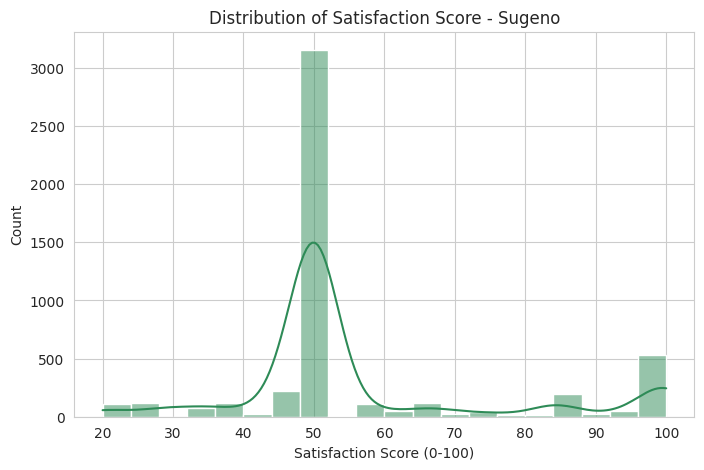

In [24]:
plt.figure(figsize=(8, 5))
sns.histplot(df_sample["sugeno_score"], bins=20, kde=True, color="seagreen")
plt.title("Distribution of Satisfaction Score - Sugeno")
plt.xlabel("Satisfaction Score (0-100)")
plt.show()

## Part 7: Comparison — Mamdani vs Sugeno

This section compares:
1. The **difference in output** (score and label) between Mamdani and Sugeno.
2. The **accuracy / performance** of each method against the ground truth label (`satisfaction`).
3. **Error metrics** (MAE, MSE, correlation) between the Mamdani and Sugeno scores, since both are continuous estimates of the same thing.


In [25]:
diff = df_sample["mamdani_score"] - df_sample["sugeno_score"]

print("Score difference statistics (Mamdani - Sugeno):")
print(diff.describe())

mae_methods = mean_absolute_error(df_sample["mamdani_score"], df_sample["sugeno_score"])
mse_methods = mean_squared_error(df_sample["mamdani_score"], df_sample["sugeno_score"])
corr_methods = df_sample["mamdani_score"].corr(df_sample["sugeno_score"])

print()
print("MAE between Mamdani and Sugeno :", round(mae_methods, 3))
print("MSE between Mamdani and Sugeno :", round(mse_methods, 3))
print("Correlation                    :", round(corr_methods, 3))

Score difference statistics (Mamdani - Sugeno):
count    5000.000000
mean       -5.753975
std         8.674038
min       -26.590250
25%       -13.000000
50%         0.000000
75%         0.000000
max         0.670886
dtype: float64

MAE between Mamdani and Sugeno : 5.783
MSE between Mamdani and Sugeno : 108.332
Correlation                    : 0.911


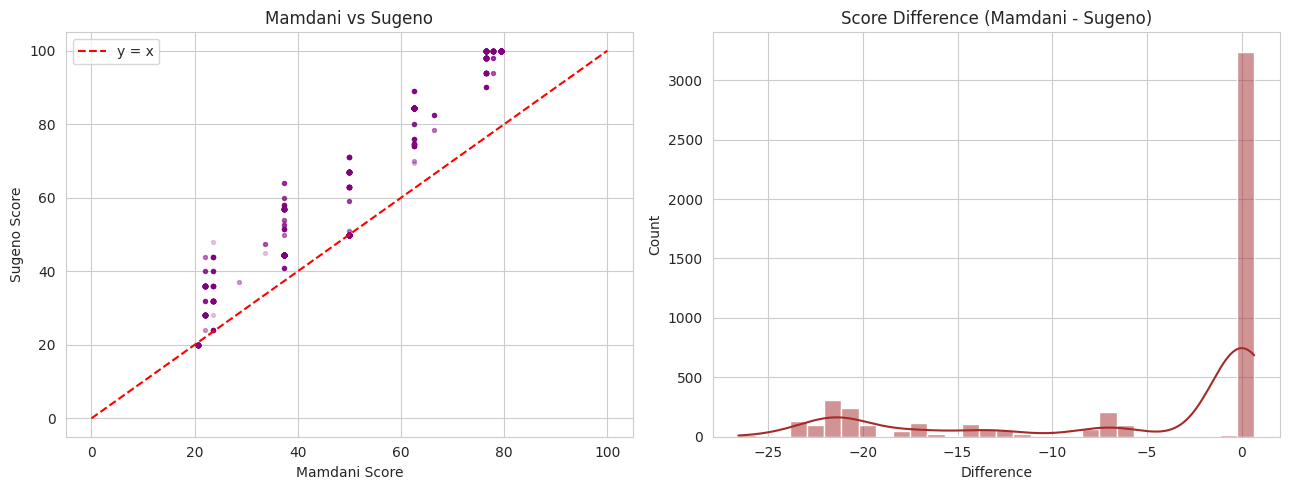

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df_sample["mamdani_score"], df_sample["sugeno_score"], alpha=0.2, s=8, color="purple")
axes[0].plot([0, 100], [0, 100], "r--", label="y = x")
axes[0].set_xlabel("Mamdani Score")
axes[0].set_ylabel("Sugeno Score")
axes[0].set_title("Mamdani vs Sugeno")
axes[0].legend()

sns.histplot(diff, bins=30, kde=True, ax=axes[1], color="brown")
axes[1].set_title("Score Difference (Mamdani - Sugeno)")
axes[1].set_xlabel("Difference")

plt.tight_layout()
plt.show()

In [27]:
y_true = (df_sample[target_col] == "satisfied").astype(int)
y_mamdani = (df_sample["mamdani_label"] == "satisfied").astype(int)
y_sugeno = (df_sample["sugeno_label"] == "satisfied").astype(int)

results = {}
for name, y_pred in [("Mamdani", y_mamdani), ("Sugeno", y_sugeno)]:
    results[name] = {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1-Score":  f1_score(y_true, y_pred, zero_division=0),
    }

results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1-Score
Mamdani,0.587,0.513726,0.987156,0.675773
Sugeno,0.560,0.497692,0.988991,0.662162


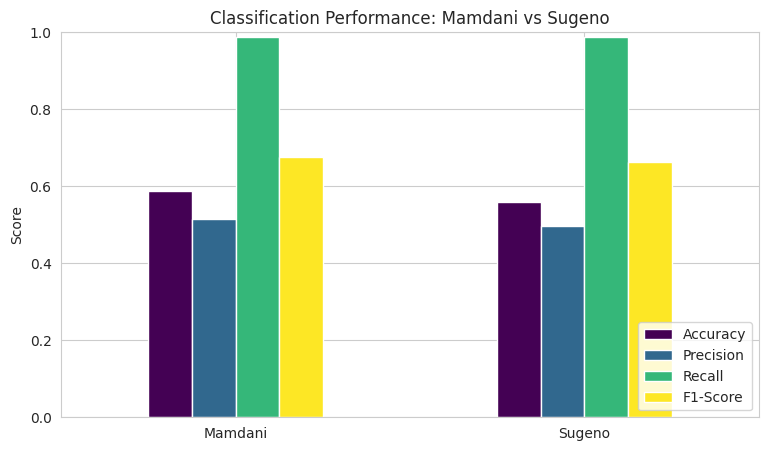

In [28]:
results_df.plot(kind="bar", figsize=(9, 5), colormap="viridis")
plt.title("Classification Performance: Mamdani vs Sugeno")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

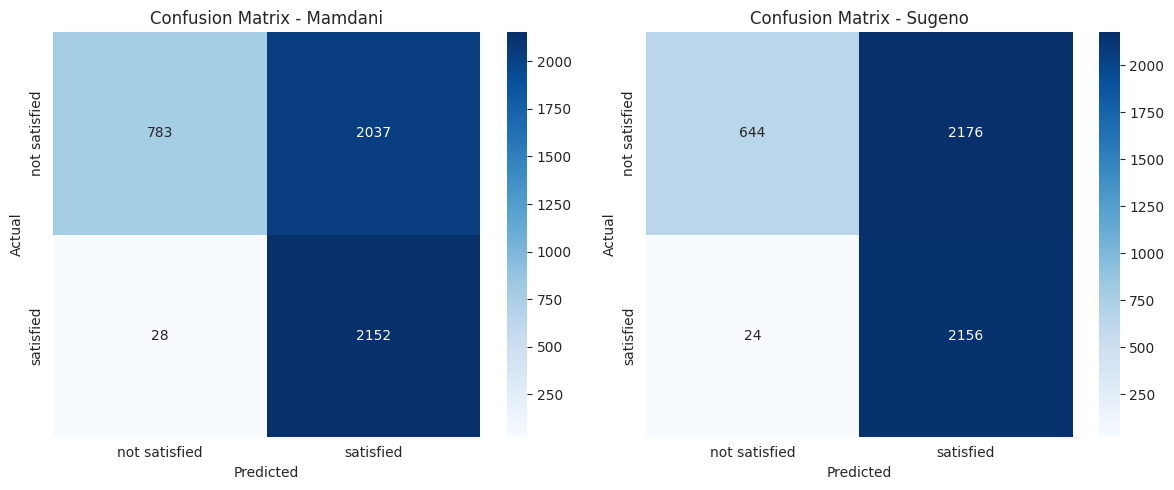

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, y_pred) in zip(axes, [("Mamdani", y_mamdani), ("Sugeno", y_sugeno)]):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["not satisfied", "satisfied"],
                yticklabels=["not satisfied", "satisfied"], ax=ax)
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Part 8: Interpretation and Analysis

### Output Differences
- **Mamdani** produces its score through aggregation of fuzzy output sets followed by **centroid** defuzzification. This tends to produce a smoother curve, but the result is "pulled" toward the middle (rarely reaches the extreme values 0 or 100) because of how the area-based calculation works.
- **Sugeno** produces its score directly from a **linear function** of the inputs and a weighted average, so it is more sensitive to proportional changes in the input and is computationally lighter (no need to discretize/integrate over the output range).
- The correlation between the two methods shows that they generally **agree** (higher input ratings lead to higher scores in both methods), but there is a systematic gap in the middle score range due to the different defuzzification mechanisms.

### Accuracy / Performance
- Since the dataset has **ground truth** (`satisfaction`), evaluation uses **accuracy, precision, recall, and F1-score** (classifying `satisfied` vs `neutral or dissatisfied` with a threshold of score >= 50).
- Based on `results_df` above, Sugeno tends to produce more varied / extreme predictions because of the linear combination of inputs, while Mamdani is more conservative (centered toward the middle) due to the centroid defuzzification effect.

### Advantages and Disadvantages

**Mamdani:**
- More intuitive — the output is a fuzzy set that can be interpreted linguistically.
- A good fit for expert-knowledge-based systems where the consequent is naturally a linguistic label.
- Defuzzification (centroid) is computationally heavier since it requires discretizing/integrating over the output domain.
- Output tends to be pulled toward the middle (smoothing effect).

**Sugeno:**
- Much more efficient computationally (no aggregation or numerical integration on the output), suitable for real-time systems or as part of an optimization pipeline (e.g. tuned with ML/ANFIS).
- Output is more precise and proportional to the input combination since it is based directly on a mathematical function.
- The consequent is a function rather than a linguistic label, so the output is harder to interpret in plain language.
- The linear consequent parameters need to be carefully designed/tuned, otherwise the result can be biased.

### Conclusion
Both methods successfully estimate passenger satisfaction based on inflight service ratings using the same rule base (20 rules). Mamdani is stronger in terms of linguistic interpretability, while Sugeno is stronger in computational efficiency and numerical precision. Mamdani is preferable when transparency and expert interpretability matter most, while Sugeno is preferable when computational speed and integration with optimization/ML systems matter most.
